<a href="https://colab.research.google.com/github/chaehyeonkim-lab/bioinformatics1/blob/main/Binformatics_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIN28A가 결합하지만 번역 억제를 받지 않는 ER-associated mRNA 후보 탐색

논문에서의 흐름은 다음과 같다.

LIN28A가 mRNA에 결합한다. 특히 ER/membrane/secretory 관련 mRNA에 많이 결합하는데, 이들은 LIN28A을 knockdown한 경우 ribosome의 density가 증가하는 경향성을 보였다. 따라서 LIN28A는 ER-associated translation을 억제한다.

하지만 여기에는 분명히 예외가 존재한다.

LIN28A가 결합하는 ER-associated mRNA임에도 불구하고, Lin28a knockdown 후 ribosome density가 증가하지 않는 mRNA는 실제로 논문의 Figure 5.B에서도 확인 가능하다.


다음과 같이 그룹을 분류 가능하다.

LIN28A-bound ER mRNA
- CLIP enrichment가 높음
- localization annotation상 ER/membrane/secretory 관련

  1. Suppressed ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density 증가
   - 원래 LIN28A가 번역을 억제했을 가능성이 높음

  2. Escapee ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density가 증가하지 않음
   - LIN28A가 붙었지만 번역 억제 효과가 뚜렷하지 않음

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/hyeshik/colab-biolab.git
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

Cloning into 'colab-biolab'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 76 (delta 26), reused 59 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 318.16 KiB | 26.51 MiB/s, done.
Resolving deltas: 100% (26/26), done.
./
./root/
./root/.bashrc.biolab
./root/.tmux.conf
./root/.profile
./root/.condarc
./root/.vimrc
./root/.bin.priority/
./root/.bin.priority/pip2
./root/.bin.priority/pip3
./root/.bin.priority/pip
--2026-06-04 04:51:58--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163179296 (156M) [application/octet-stream]
Saving to: ‘miniconda3.sh’

miniconda3.sh       100%[===================>] 

In [3]:
!ls -al /content/drive/MyDrive/binfo1-datapack1/

total 7162852
-r-------- 1 root root 1370036258 Apr 27  2023 CLIP-35L33G.bam
-r-------- 1 root root    3118336 Apr 27  2023 CLIP-35L33G.bam.bai
-r-------- 1 root root       7113 May 11  2023 CLIP-let7g.bam
-r-------- 1 root root      14561 May 11  2023 CLIP-let7g-gene.pileup
-r-------- 1 root root    2685065 May 11  2023 CLIP-let7g.pileup
-r-------- 1 root root  883334756 Apr 27  2023 gencode.gtf
-r-------- 1 root root   24065406 Apr 27  2023 read-counts.txt
-r-------- 1 root root        751 Apr 27  2023 read-counts.txt.summary
-r-------- 1 root root 1003658801 Apr 27  2023 RNA-control.bam
-r-------- 1 root root    2276104 Apr 27  2023 RNA-control.bam.bai
-r-------- 1 root root 1260991122 Apr 27  2023 RNA-siLin28a.bam
-r-------- 1 root root    2710744 Apr 27  2023 RNA-siLin28a.bam.bai
-r-------- 1 root root  981684502 Apr 27  2023 RNA-siLuc.bam
-r-------- 1 root root    2606104 Apr 27  2023 RNA-siLuc.bam.bai
-r-------- 1 root root  737352902 Apr 27  2023 RPF-siLin28a.bam
-r-------- 1 r

In [4]:
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install -y subread

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: / - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - subread


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    conda-26.3.2               |  py313h78bf25f_1         1.2 MB  conda-forge
    openssl-

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [19]:
cnts = pd.read_csv(
    '/content/drive/MyDrive/binfo1-datapack1/read-counts.txt',
    sep='\t',
    comment='#',
    index_col=0
)

# 분석에 사용할 count column들입니다.
# Length는 유전자 길이 정보이므로 library size 계산에서 제외해야 합니다.
count_cols = [
    'CLIP-35L33G.bam',
    'RNA-control.bam',
    'RNA-siLuc.bam',
    'RNA-siLin28a.bam',
    'RPF-siLuc.bam',
    'RPF-siLin28a.bam'
]

# 혹시 파일에 예상한 column이 없으면 바로 에러를 내도록 확인합니다.
missing_cols = [col for col in count_cols if col not in cnts.columns]
if len(missing_cols) > 0:
    raise ValueError(f"다음 column이 read-counts.txt에 없습니다: {missing_cols}")

# 원본 count table 복사
df = cnts.copy()

# ------------------------------------------------------------
# 1) Library size 계산
# ------------------------------------------------------------
# 각 BAM file별 전체 read count 합입니다.
# 쉽게 말하면, 각 샘플에서 총 몇 개의 read가 잡혔는지 계산하는 단계입니다.
library_sizes = df[count_cols].sum(axis=0)

print("Library sizes")
display(library_sizes.to_frame(name='total_counts'))

# ------------------------------------------------------------
# 2) CPM 계산
# ------------------------------------------------------------
# CPM = counts per million
# 각 샘플의 read 수 차이를 맞추기 위해,
# "이 유전자의 read가 전체 100만 read 중 몇 개에 해당하는가"로 바꿉니다.
cpm = df[count_cols].div(library_sizes, axis=1) * 1_000_000

# CPM column 이름을 따로 붙입니다.
# 예: RNA-siLuc.bam -> RNA-siLuc.bam_cpm
cpm = cpm.add_suffix('_cpm')

# 원래 df에 CPM column들을 붙입니다.
df = pd.concat([df, cpm], axis=1)

# ------------------------------------------------------------
# 3) 너무 낮은 RNA count를 가진 gene 제거
# ------------------------------------------------------------
# RNA read count가 너무 낮으면 RPF/RNA 비율이 불안정합니다.
# 여기서는 기존 노트북과 똑같이 raw RNA count > 10 기준을 유지합니다.
df = df[
    (df['RNA-control.bam'] > 10) &
    (df['RNA-siLuc.bam'] > 10) &
    (df['RNA-siLin28a.bam'] > 10)
].copy()

# ------------------------------------------------------------
# 4) CPM-normalized 값으로 핵심 지표 계산
# ------------------------------------------------------------
# pseudo_cpm은 0으로 나누는 것을 막기 위해 더하는 작은 값입니다.
# raw count에 1을 더하던 것과 같은 목적이지만,
# 이제 값의 단위가 CPM이므로 0.1 CPM을 사용합니다.
pseudo_cpm = 0.1

# LIN28A 결합 강도
# 기존: raw CLIP / raw RNA-control
# 수정: CPM CLIP / CPM RNA-control
df['clip_log2'] = np.log2(
    (df['CLIP-35L33G.bam_cpm'] + pseudo_cpm) /
    (df['RNA-control.bam_cpm'] + pseudo_cpm)
)

# control 조건의 ribosome density
# 기존: raw RPF-siLuc / raw RNA-siLuc
# 수정: CPM RPF-siLuc / CPM RNA-siLuc
df['rden_siLuc'] = (
    (df['RPF-siLuc.bam_cpm'] + pseudo_cpm) /
    (df['RNA-siLuc.bam_cpm'] + pseudo_cpm)
)

# Lin28a knockdown 조건의 ribosome density
# 기존: raw RPF-siLin28a / raw RNA-siLin28a
# 수정: CPM RPF-siLin28a / CPM RNA-siLin28a
df['rden_siLin28a'] = (
    (df['RPF-siLin28a.bam_cpm'] + pseudo_cpm) /
    (df['RNA-siLin28a.bam_cpm'] + pseudo_cpm)
)

# Lin28a knockdown 후 ribosome density 변화
# 양수면: knockdown 후 ribosome density 증가
# 음수면: knockdown 후 ribosome density 감소
df['rden_log2'] = np.log2(
    df['rden_siLin28a'] / df['rden_siLuc']
)

# RNA abundance 변화
# 기존: raw RNA-siLin28a / raw RNA-siLuc
# 수정: CPM RNA-siLin28a / CPM RNA-siLuc
df['rna_change_log2'] = np.log2(
    (df['RNA-siLin28a.bam_cpm'] + pseudo_cpm) /
    (df['RNA-siLuc.bam_cpm'] + pseudo_cpm)
)

# inf, -inf, NaN 제거
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['clip_log2', 'rden_log2', 'rna_change_log2'])

print("분석에 남은 gene 수:", len(df))

df[
    [
        'Length',
        'clip_log2',
        'rden_siLuc',
        'rden_siLin28a',
        'rden_log2',
        'rna_change_log2'
    ]
].head()

Library sizes


,total_counts
CLIP-35L33G.bam,13630945
RNA-control.bam,5200836
RNA-siLuc.bam,9748787
RNA-siLin28a.bam,12338280
RPF-siLuc.bam,12932285
RPF-siLin28a.bam,10694162


분석에 남은 gene 수: 12937


,Length,clip_log2,rden_siLuc,rden_siLin28a,rden_log2,rna_change_log2
Geneid,,,,,,
ENSMUSG00000102343.2,1364,-0.273124,0.015715,0.011466,-0.454788,0.058663
ENSMUSG00000102269.2,2991,-4.363151,0.647971,0.121137,-2.419287,0.947781
ENSMUSG00000098104.2,1470,-2.454964,0.391346,0.130033,-1.589564,0.429748
ENSMUSG00000103922.2,1069,-0.441396,0.569571,0.527315,-0.111211,-0.439526
ENSMUSG00000033845.14,8487,0.176614,0.938565,0.709848,-0.402947,-0.102136


In [20]:
!curl -k -L -o mouselocalization-20210507.txt https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt

import pandas as pd

local = pd.read_csv('mouselocalization-20210507.txt', sep='\t')
local.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
curl: (35) OpenSSL SSL_connect: Connection reset by peer in connection to hyeshik.qbio.io:443 


,gene_id,Gene names,type
0,ENSMUSG00000000001,Gnai3,cytoplasm
1,ENSMUSG00000000028,Cdc45 Cdc45l Cdc45l2,nucleus
2,ENSMUSG00000000049,Apoh B2gp1,cytoplasm
3,ENSMUSG00000000058,Cav2,cytoplasm
4,ENSMUSG00000000085,Scmh1,nucleus


In [21]:
# df: read-counts.txt에서 계산한 표
# local: mouselocalization-20210507.txt에서 읽은 표

merged = df.copy().reset_index()

# reset_index() 후 첫 번째 column이 gene id입니다.
# 이름을 gene_id_count로 바꿔줍니다.
merged = merged.rename(columns={merged.columns[0]: 'gene_id_count'})

# gene id 뒤에 버전 번호가 붙어 있을 수 있으므로 제거합니다.
# 예: ENSMUSG00000000001.4 -> ENSMUSG00000000001
merged['gene_id_base'] = (
    merged['gene_id_count']
    .astype(str)
    .str.replace(r'\.\d+$', '', regex=True)
)

local2 = local.copy()

local2['gene_id_base'] = (
    local2['gene_id']
    .astype(str)
    .str.replace(r'\.\d+$', '', regex=True)
)

# 같은 gene_id가 여러 번 있을 수 있으므로 하나로 합칩니다.
local2 = (
    local2
    .groupby('gene_id_base', as_index=False)
    .agg({
        'Gene names': lambda x: '; '.join(sorted(set(x.astype(str)))),
        'type': lambda x: '; '.join(sorted(set(x.astype(str))))
    })
)

# read count 정보와 localization 정보를 합칩니다.
merged = merged.merge(local2, on='gene_id_base', how='left')

print("전체 gene 수:", len(merged))
print("localization annotation이 붙은 gene 수:", merged['type'].notna().sum())
print("localization annotation이 없는 gene 수:", merged['type'].isna().sum())

merged[['gene_id_count', 'Gene names', 'type', 'clip_log2', 'rden_log2', 'rna_change_log2']].head()

전체 gene 수: 12937
localization annotation이 붙은 gene 수: 6223
localization annotation이 없는 gene 수: 6714


,gene_id_count,Gene names,type,clip_log2,rden_log2,rna_change_log2
0,ENSMUSG00000102343.2,NaN,NaN,-0.273124,-0.454788,0.058663
1,ENSMUSG00000102269.2,NaN,NaN,-4.363151,-2.419287,0.947781
2,ENSMUSG00000098104.2,NaN,NaN,-2.454964,-1.589564,0.429748
3,ENSMUSG00000103922.2,NaN,NaN,-0.441396,-0.111211,-0.439526
4,ENSMUSG00000033845.14,NaN,NaN,0.176614,-0.402947,-0.102136


In [22]:
# 현재 localization 파일에서는 integral membrane이 ER-associated translation과 가장 가까운 proxy입니다.
# 그래도 혹시 다른 단어가 있을 경우를 대비해서 pattern을 넓게 잡습니다.

er_pattern = r'integral membrane|membrane|secret|endoplasmic|reticulum|golgi|lumen|extracellular|cell surface|plasma membrane'

merged['er_related'] = (
    merged['type']
    .astype(str)
    .str.contains(er_pattern, case=False, regex=True, na=False)
)

print(merged['er_related'].value_counts())

merged.loc[
    merged['er_related'],
    ['gene_id_count', 'Gene names', 'type']
].head(20)

er_related
False    11387
True      1550
Name: count, dtype: int64


,gene_id_count,Gene names,type
47,ENSMUSG00000032769.6,Trpa1 Anktm1,integral membrane
50,ENSMUSG00000025921.8,Rdh10,integral membrane
56,ENSMUSG00000042686.6,Jph1 Jp1,integral membrane
61,ENSMUSG00000025931.16,Paqr8 Mprb,integral membrane
64,ENSMUSG00000025933.16,Tmem14a,integral membrane
69,ENSMUSG00000026156.9,B3gat2 Glcats,integral membrane
80,ENSMUSG00000073725.9,Lmbrd1,integral membrane
90,ENSMUSG00000026131.21,Dst Bpag1 Macf2,integral membrane
97,ENSMUSG00000037503.13,Fam168b Kiaa4042,integral membrane
98,ENSMUSG00000026123.12,Plekhb2 Evt2,integral membrane


In [23]:
# LIN28A 결합 강도 상위 10%를 strong binder로 정의합니다.
clip_cutoff = merged['clip_log2'].quantile(0.90)

print("LIN28A strong binding cutoff:", clip_cutoff)

# 조건 정의
strong_binding = merged['clip_log2'] >= clip_cutoff
er_related = merged['er_related']

# mRNA abundance가 크게 감소하지 않는 조건
# log2 fold change가 -0.5 이상이면 약 0.71배 이상 유지된다는 뜻입니다.
rna_not_decreased = merged['rna_change_log2'] >= -0.5

# Lin28a knockdown 후 ribosome density가 증가한 경우
translation_derepressed = merged['rden_log2'] > 0.5

# Lin28a knockdown 후 ribosome density가 증가하지 않은 경우
translation_escapee = merged['rden_log2'] <= 0

merged['group'] = 'Other'

merged.loc[
    strong_binding & er_related & rna_not_decreased,
    'group'
] = 'LIN28A-bound ER-related mRNA'

merged.loc[
    strong_binding & er_related & rna_not_decreased & translation_derepressed,
    'group'
] = 'Suppressed-like ER target'

merged.loc[
    strong_binding & er_related & rna_not_decreased & translation_escapee,
    'group'
] = 'Escapee ER target'

merged['group'].value_counts()

LIN28A strong binding cutoff: 0.9894498781240465


,count
group,
Other,12607
Suppressed-like ER target,203
LIN28A-bound ER-related mRNA,105
Escapee ER target,22


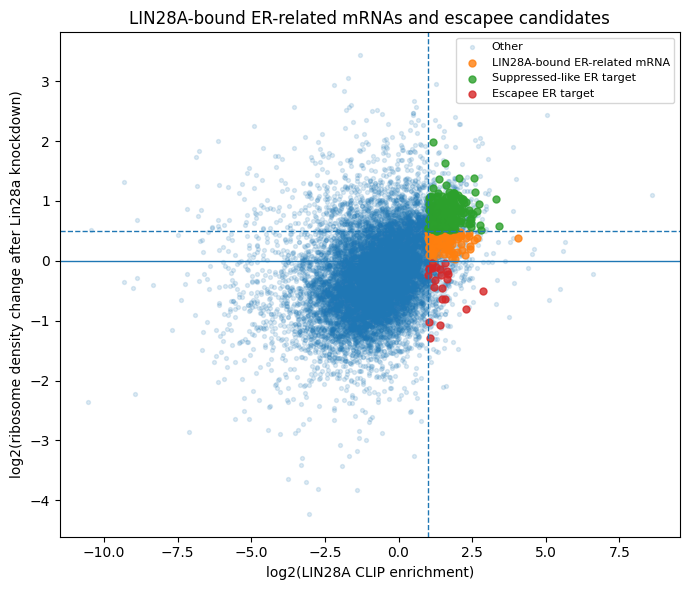

In [24]:
plt.figure(figsize=(7, 6))

# Other는 배경처럼 연하게 찍기
other = merged[merged['group'] == 'Other']

plt.scatter(
    other['clip_log2'],
    other['rden_log2'],
    s=8,
    alpha=0.15,
    label='Other'
)

# 주요 그룹만 따로 강조
for group_name in [
    'LIN28A-bound ER-related mRNA',
    'Suppressed-like ER target',
    'Escapee ER target'
]:
    sub = merged[merged['group'] == group_name]

    plt.scatter(
        sub['clip_log2'],
        sub['rden_log2'],
        s=25,
        alpha=0.8,
        label=group_name
    )

plt.axvline(clip_cutoff, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.axhline(0.5, linestyle='--', linewidth=1)

plt.xlabel('log2(LIN28A CLIP enrichment)')
plt.ylabel('log2(ribosome density change after Lin28a knockdown)')
plt.title('LIN28A-bound ER-related mRNAs and escapee candidates')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [25]:
escapees = merged[merged['group'] == 'Escapee ER target'].copy()

# 해석하기 쉽게 정렬합니다.
# 1순위: LIN28A 결합이 강한 것
# 2순위: rden_log2가 낮은 것
# 3순위: RNA 변화가 0에 가까운 것
escapees['abs_rna_change'] = escapees['rna_change_log2'].abs()

escapees = escapees.sort_values(
    ['clip_log2', 'rden_log2', 'abs_rna_change'],
    ascending=[False, True, True]
)

cols = [
    'gene_id_count',
    'Gene names',
    'type',
    'Length',
    'clip_log2',
    'rden_log2',
    'rna_change_log2',
    'rden_siLuc',
    'rden_siLin28a'
]

escapees[cols].head(30)

,gene_id_count,Gene names,type,Length,clip_log2,rden_log2,rna_change_log2,rden_siLuc,rden_siLin28a
9318,ENSMUSG00000038732.16,Mboat1 Lpeat1 Oact1,integral membrane,3659,2.866154,-0.498569,0.819111,38.293876,27.104734
2339,ENSMUSG00000052430.16,Bmpr1b Acvrlk6,integral membrane,5962,2.273810,-0.798758,0.858000,0.976875,0.561551
12786,ENSMUSG00000048040.9,Arxes1; Arxes2,integral membrane,1532,1.684630,-0.228121,-0.382975,0.104398,0.089129
4455,ENSMUSG00000030286.7,Emc3 Tmem111,integral membrane,3361,1.645418,-0.167559,0.241262,1.007551,0.897071
7475,ENSMUSG00000034612.8,Chst11,integral membrane,5527,1.641081,-0.306627,0.607647,0.471819,0.381480
7567,ENSMUSG00000020189.16,Osbpl8 Kiaa1451 Orp8,integral membrane,9600,1.584574,-0.645298,0.472904,0.379524,0.242653
8318,ENSMUSG00000020521.8,Rnft1,integral membrane,4719,1.563188,-0.036152,0.296524,0.970862,0.946836
10087,ENSMUSG00000022015.9,Tnfsf11 Opgl Rankl Trance,integral membrane,2236,1.486967,-0.637290,0.642821,1.365411,0.877849
7095,ENSMUSG00000019806.14,Aig1,integral membrane,9196,1.466771,-0.456278,1.018459,1.116730,0.813944
12828,ENSMUSG00000041688.17,Amot Kiaa1071,integral membrane,8402,1.455202,-0.237074,0.297972,0.282237,0.239468


group
Suppressed-like ER target    203
Escapee ER target             22
Name: count, dtype: int64


/tmp/ipykernel_1459/2735257339.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


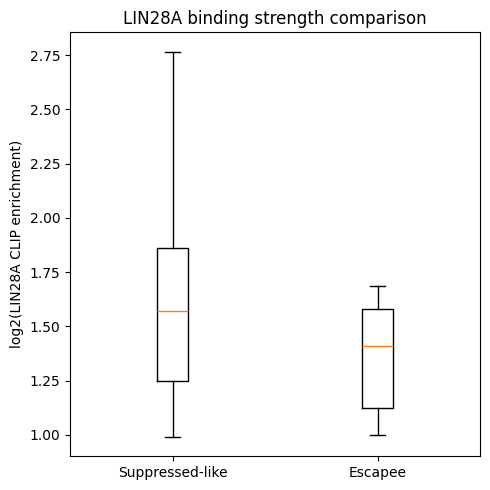

In [26]:
target_df = merged[
    merged['group'].isin(['Suppressed-like ER target', 'Escapee ER target'])
].copy()

print(target_df['group'].value_counts())

plt.figure(figsize=(5, 5))

plot_data = [
    target_df.loc[target_df['group'] == 'Suppressed-like ER target', 'clip_log2'],
    target_df.loc[target_df['group'] == 'Escapee ER target', 'clip_log2']
]

plt.boxplot(
    plot_data,
    labels=['Suppressed-like', 'Escapee'],
    showfliers=False
)

plt.ylabel('log2(LIN28A CLIP enrichment)')
plt.title('LIN28A binding strength comparison')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1459/3284811208.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


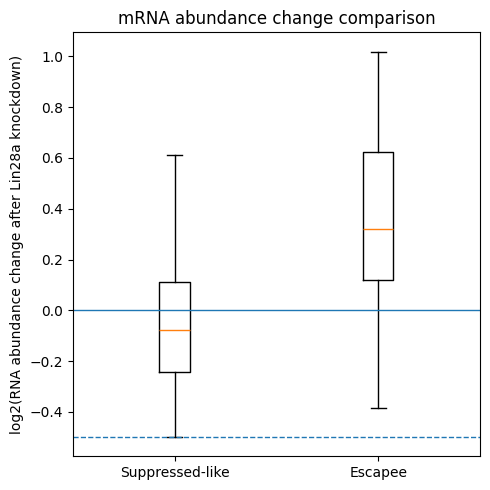

In [27]:
plt.figure(figsize=(5, 5))

plot_data = [
    target_df.loc[target_df['group'] == 'Suppressed-like ER target', 'rna_change_log2'],
    target_df.loc[target_df['group'] == 'Escapee ER target', 'rna_change_log2']
]

plt.boxplot(
    plot_data,
    labels=['Suppressed-like', 'Escapee'],
    showfliers=False
)

plt.axhline(0, linewidth=1)
plt.axhline(-0.5, linestyle='--', linewidth=1)

plt.ylabel('log2(RNA abundance change after Lin28a knockdown)')
plt.title('mRNA abundance change comparison')

plt.tight_layout()
plt.show()

In [28]:
escapees[cols].to_csv('LIN28A_ER_escapee_candidates.csv', index=False)

target_df[cols + ['group']].to_csv('LIN28A_ER_target_groups.csv', index=False)

print("저장 완료:")
print("1. LIN28A_ER_escapee_candidates.csv")
print("2. LIN28A_ER_target_groups.csv")

저장 완료:
1. LIN28A_ER_escapee_candidates.csv
2. LIN28A_ER_target_groups.csv


In [ ]:
from google.colab import files

files.download('LIN28A_ER_escapee_candidates.csv')
files.download('LIN28A_ER_target_groups.csv')